In [ ]:
%pip install qiskit matplotlib numpy
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector, plot_histogram

#Question 1 — Build the state |01⟩
#Build the state |01⟩ using one gate, and confirm the printed outcome matches what you expect.

[0.+0.j 1.+0.j 0.+0.j 0.+0.j]


<IPython.core.display.Latex object>

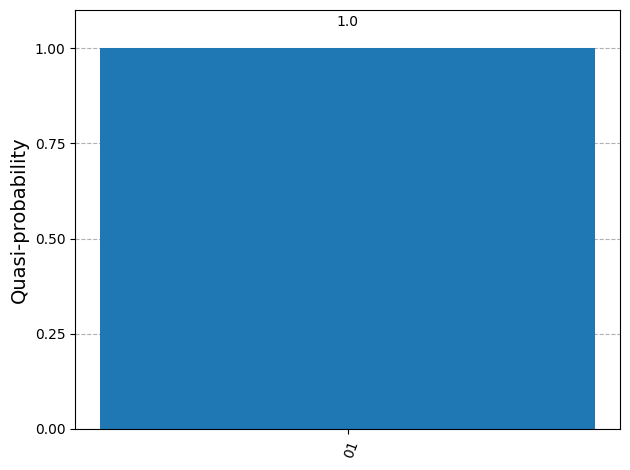

In [ ]:
qc = QuantumCircuit(2)
qc.x(0)
sv = Statevector(qc)

##verify
print(sv.data)
display(sv.draw("latex"))
plot_histogram(sv.probabilities_dict())

#Question 2 — Toffoli gate prediction  
#Predict the final outcome of the described 3 qubit circuit before building it, then confirm your prediction.

[[0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]]


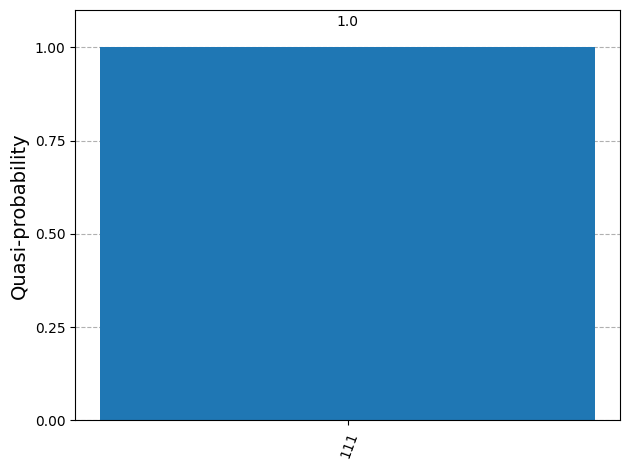

In [ ]:
qc = QuantumCircuit(3)
qc.x(0)
qc.x(1)
qc.ccx(0, 1, 2)

sv=Statevector(qc)
##verify
print(np.real(Operator(qc).data))
plot_histogram(sv.probabilities_dict())

# Question 3 — CNOT from H and CZ only  
# Build an exact copy of CNOT using only H and CZ gates, no cx allowed, and verify the matrix matches

In [ ]:
CTRL, TGT = 0, 1

##original
orig = QuantumCircuit(2)
orig.cx(CTRL, TGT)
sv_original=Statevector(orig)
print(sv_original)
print(np.real(Operator(orig).data))

##custom
qc = QuantumCircuit(2)
qc.h(TGT)
qc.cz(CTRL, TGT)
qc.h(TGT)
sv_result=Statevector(qc)
print(sv_result)
print(np.real(Operator(qc).data))

#verify
print("exact match:", np.allclose(Operator(orig).data, Operator(qc).data))


Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]
Statevector([ 1.00000000e+00+0.j,  0.00000000e+00+0.j, -2.23711432e-17+0.j,
              0.00000000e+00+0.j],
            dims=(2, 2))
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]
exact match: True


# Question 4 — CNOT on an already-1 control  

# Predict the result of applying CNOT to the state |11⟩ before building it, then confirm your prediction.

#### Expected: In Qiskit, writing cx(0, 1) ,the rightmost 1 is the untouched control, the leftmost 0 is the flipped target

[[0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]


<IPython.core.display.Latex object>

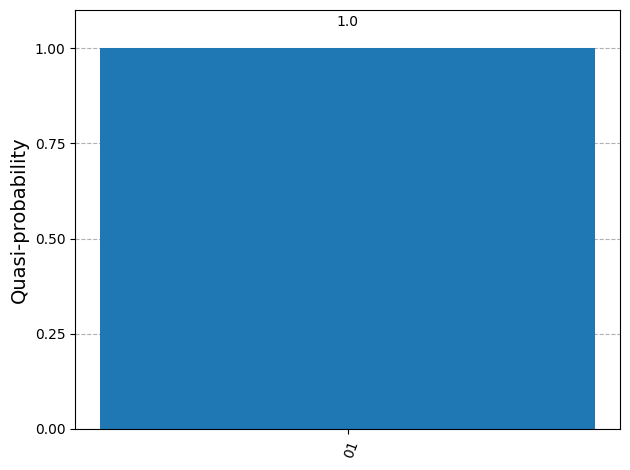

In [ ]:
qc = QuantumCircuit(2)

##prepare 11
qc.x(0)
qc.x(1)

##apply cnot
qc.cx(0, 1)

sv=Statevector(qc)
##verify
print(np.real(Operator(qc).data))
display(sv.draw("latex"))
plot_histogram(sv.probabilities_dict())


# Question 5 — Two independent Hadamards

# Predict the histogram shape for two independently Hadamard qubits before building the circuit, then confirm your prediction.

#### Expected - The two-Hadamard state has all four outcomes and is separable

<IPython.core.display.Latex object>

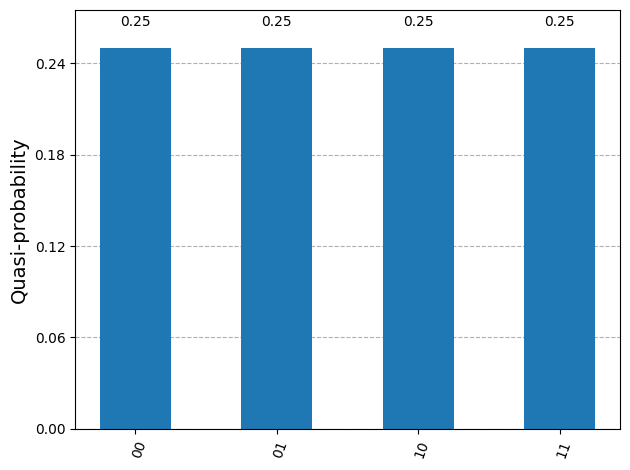

In [ ]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)

sv = Statevector(qc)
display(sv.draw("latex"))
plot_histogram(sv.probabilities_dict())

# Question 6 — SWAP from CNOTs only  

# Build an exact copy of SWAP using only CNOT gates, no swap allowed, and verify the matrix matches.

In [ ]:
orig = QuantumCircuit(2)
orig.swap(0, 1)
sv_original=Statevector(orig)
print(sv_original)
print(np.real(Operator(orig).data))

qc = QuantumCircuit(2)
qc.cx(0, 1)
qc.cx(1, 0)
qc.cx(0, 1)
sv_result=Statevector(qc)
print(sv_result)
print(np.real(Operator(qc).data))

#verify
print("exact match:", np.allclose(Operator(orig).data, Operator(qc).data))


Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]
Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]
exact match: True
